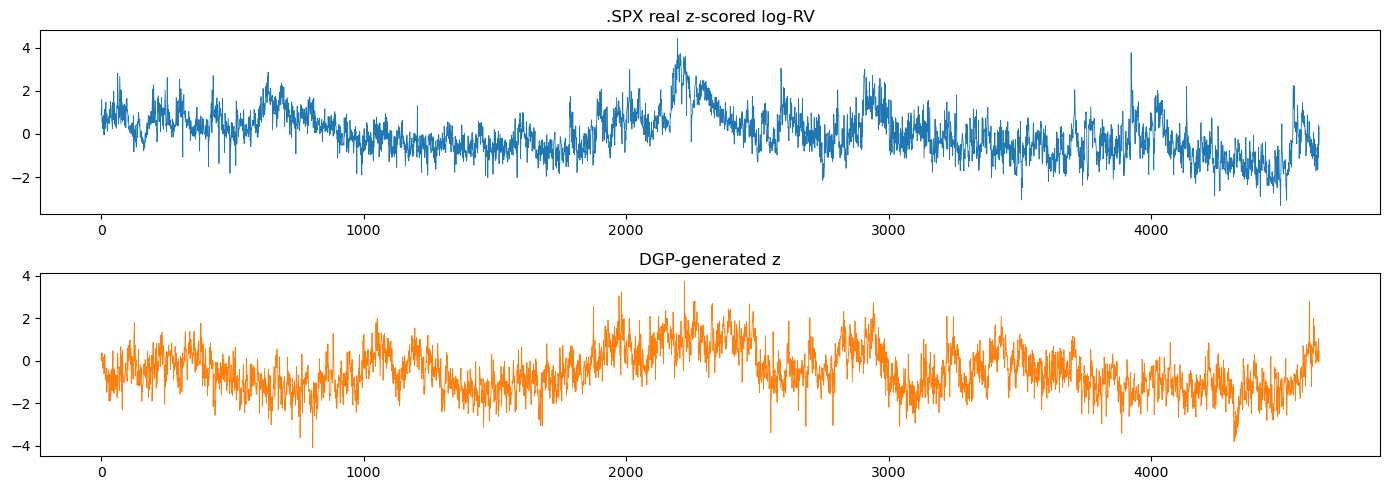

In [4]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, "/Users/yannkerzreho/Documents/PR/sg/sasfi")

from data.data_loader import load_rv, fit_scaler, apply_scaler
from experiments.exp_dgp_sas import SASDGP, _fit_dgp

SYM, Q, P, N_RES, DGP_SEED, NU = ".SPX", 2, 1, 200, 42, 10
CSV = "/Users/yannkerzreho/Documents/PR/sg/sasfi/rv.csv"

log_vals, _ = load_rv(CSV, SYM)
mu, sd = fit_scaler(log_vals)
z_real = apply_scaler(log_vals, mu, sd)

model, sigma = _fit_dgp(log_vals, Q, P, N_RES, DGP_SEED)
z_syn = SASDGP(model, sigma, nu=NU).generate(len(z_real), seed=DGP_SEED)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)
axes[0].plot(z_real, lw=0.6)
axes[0].set_title(f"{SYM} real z-scored log-RV")
axes[1].plot(z_syn, lw=0.6, c="tab:orange")
axes[1].set_title("DGP-generated z")
plt.tight_layout(); plt.show()